In [1]:
import pandas as pd
import scipy.stats
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import TargetEncoder
from concurrent.futures import ThreadPoolExecutor
import itertools
import gc
from lightgbm import LGBMClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import warnings
warnings.filterwarnings("ignore")

Again, we use an unconventional naming scheme here: 
- training
- testing
- out-of-time validation set

We leave the validation set out for real out-of-time prediction, and for the rest, we apply a k-fold cross validation.

### Data Prep

In [15]:
df = pd.read_parquet('data/candidate_variables.parquet')
df.Date.min(), df.Date.max()

(Timestamp('2010-01-15 00:00:00'), Timestamp('2010-10-31 00:00:00'))

In [19]:
df.columns

Index(['Recnum', 'Date', 'Cardnum', 'Merchnum', 'Amount', 'Fraud',
       'Merch description', 'Merch state', 'Merch zip', 'DayOfWeek',
       ...
       'merchnum_zip3_count_1_by_60_sq', 'distance_to_last_transaction',
       'suspicious_distance_flag', 'amount_category', 'foreign_zip_flag',
       'is_weekend', 'amount_is_rounded', 'high_amount_for_merchant',
       'merchant_dominance_score', 'state_inconsistency_flag'],
      dtype='object', length=6883)

In [20]:
df_oot = df[df.Date >= '2010-11-01']
df_train_test = df[df.Date < '2010-11-01']

In [21]:
selected_features = pd.read_csv('data/selected_features_ks.csv')
TOP_NVAR = 18
selected_features = selected_features['feature'].tolist()[:TOP_NVAR]

In [22]:
selected_features

['Cardnum_vdratio_1by14',
 'card_merchdesc_zip_total_14',
 'Cardnum_unique_count_for_card_state_3',
 'merch_zip_actual/med_60',
 'card_zip_unique_count_for_merchnum_dow_60',
 'Cardnum_count_1_by_7',
 'card_dow_unique_count_for_card_merchnum_zip_60',
 'card_state_variability_max_3',
 'merchnum_desc_state_actual/avg_60',
 'Cardnum_count_1_by_7_sq',
 'Cardnum_unique_count_for_card_dow_1',
 'card_dow_actual/med_7',
 'card_dow_actual/avg_7',
 'card_dow_actual/max_7',
 'card_dow_unique_count_for_merch_zip_60',
 'card_dow_unique_count_for_Merchnum_60',
 'card_dow_unique_count_for_merch_state_60',
 'card_dow_unique_count_for_card_merch_60']

The model building pipeline is delineated as follows:

1. Robust Scaler
2. Clip outliers
3. Standard Scaler
4. PCA (Optional)
5. Model building

### Exploratory Analysis for PCA

Before we do that, though, we should implement exploratory analysis and visualize variance as a function of number of components.

In [23]:
X_train_test = df_train_test[selected_features]

In [25]:
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA

CLIP_THRESHOLD = 10

robust_scaler = RobustScaler()
X_robust = robust_scaler.fit_transform(X_train_test)

X_clipped = np.clip(X_robust, -CLIP_THRESHOLD, CLIP_THRESHOLD)

standard_scaler = StandardScaler()
X_scaled = standard_scaler.fit_transform(X_clipped)

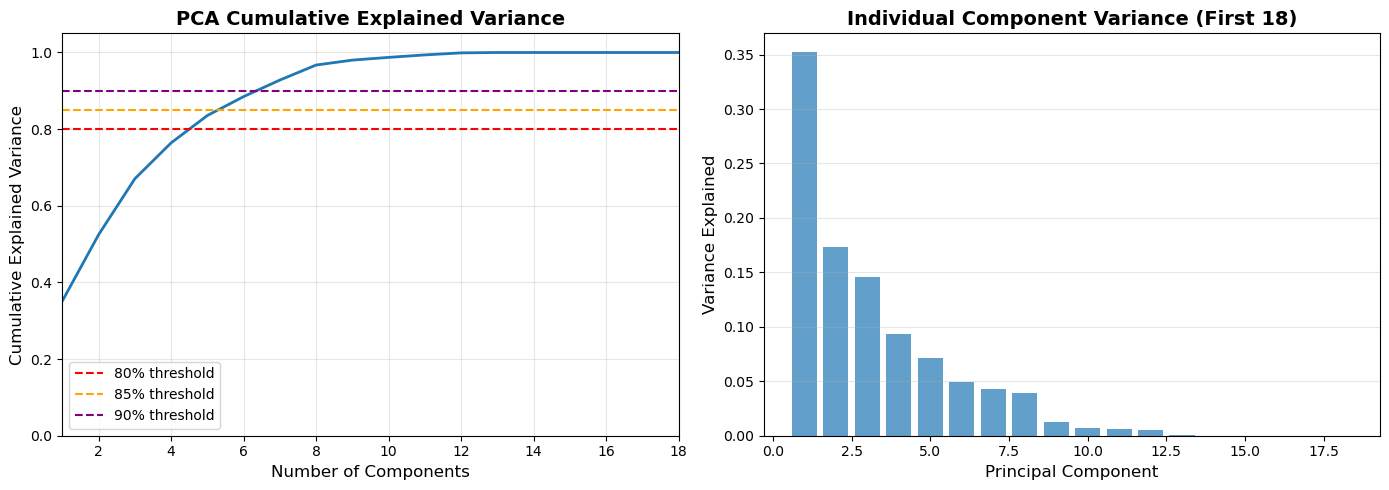

In [28]:
pca_full = PCA()
pca_full.fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)
ax1.plot(range(1, len(cumsum_var) + 1), cumsum_var, linewidth=2)
ax1.axhline(y=0.80, color='r', linestyle='--', label='80% threshold', linewidth=1.5)
ax1.axhline(y=0.85, color='orange', linestyle='--', label='85% threshold', linewidth=1.5)
ax1.axhline(y=0.90, color='purple', linestyle='--', label='90% threshold', linewidth=1.5)
ax1.set_xlabel('Number of Components', fontsize=12)
ax1.set_ylabel('Cumulative Explained Variance', fontsize=12)
ax1.set_title('PCA Cumulative Explained Variance', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.set_xlim(1, len(cumsum_var))
ax1.set_ylim(0, 1.05)

ax2 = axes[1]
n_bars = min(18, len(pca_full.explained_variance_ratio_))
ax2.bar(range(1, n_bars + 1), pca_full.explained_variance_ratio_[:n_bars], alpha=0.7)
ax2.set_xlabel('Principal Component', fontsize=12)
ax2.set_ylabel('Variance Explained', fontsize=12)
ax2.set_title(f'Individual Component Variance (First {n_bars})', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Model Building

In [10]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

def calculate_fdr_at_rate(y_true, y_pred_proba, detect_rate=0.03):
    n_top = int(round(len(y_true) * detect_rate))
    top_indices = np.argsort(y_pred_proba)[-n_top:]
    return y_true.iloc[top_indices].sum() / y_true.sum()

def evaluate_model_cv(X_train_test, y_train_test, X_oot, y_oot, 
                      n_splits=5, detect_rate=0.03, use_pca=False, n_components=None):
    """
    Returns DataFrame with FDR scores for each fold
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_test)):
        X_train, X_val = X_train_test.iloc[train_idx], X_train_test.iloc[val_idx]
        y_train, y_val = y_train_test.iloc[train_idx], y_train_test.iloc[val_idx]
        
        steps = [
            ('robust', RobustScaler()),
            ('clip', FunctionTransformer(lambda x: np.clip(x, -10, 10))),
            ('standard', StandardScaler())
        ]
        if use_pca:
            steps.append(('pca', PCA(n_components=n_components)))
        steps.append(('model', LogisticRegression(max_iter=1000)))
        
        pipeline = Pipeline(steps)
        
        pipeline.fit(X_train, y_train.values.ravel())
        
        fdr_train = calculate_fdr_at_rate(y_train, pipeline.predict_proba(X_train)[:, 1], detect_rate)
        fdr_val = calculate_fdr_at_rate(y_val, pipeline.predict_proba(X_val)[:, 1], detect_rate)
        fdr_oot = calculate_fdr_at_rate(y_oot, pipeline.predict_proba(X_oot)[:, 1], detect_rate)
        
        results.append({'fold': fold, 'train': fdr_train, 'val': fdr_val, 'oot': fdr_oot})
        print(f"Fold {fold}: Train={fdr_train:.3f}, Val={fdr_val:.3f}, OOT={fdr_oot:.3f}")
    
    results_df = pd.DataFrame(results)
    
    print(f"\nMean FDR: Train={results_df['train'].mean():.3f}, "
          f"Val={results_df['val'].mean():.3f}, OOT={results_df['oot'].mean():.3f}")
    
    return results_df

In [11]:
X_oot_full = construct_features(
    df_historical=df_train_test,
    df_current=df_oot,
    selected_features=selected_features,
    verbose=True
)

Historical data: 85400 rows
Current data: 12637 rows
Selected features: 18

[1/3] Analyzing feature requirements...
  Entities needed: 12
  Time windows needed: [1, 3, 7, 14, 60]
  Base features: 10
  Derived features: 17
  Target encoding: 0
  Business features: 0

[3/3] Computing features...
  Computing time-based features for 5 entities...


  Time features: 100%|██████████| 5/5 [00:03<00:00,  1.50it/s]


  Computing variability features for 1 entities...


  Variability: 100%|██████████| 1/1 [00:00<00:00,  4.70it/s]


  Computing unique count features for 8 entity pairs...


  Unique counts: 100%|██████████| 8/8 [00:02<00:00,  2.88it/s]

  Computing 17 derived features...
Complete: 18 features constructed


In [30]:
y_train_test = df_train_test['Fraud']
y_oot = df_oot['Fraud']

results_logreg = evaluate_model_cv(
    X_train_test, 
    y_train_test,
    X_oot_full,
    y_oot,
    n_splits=5,
    detect_rate=0.03,
    use_pca=False
)

IndexError: positional indexers are out-of-bounds

In [14]:
X_train_test_full.columns

Index(['Cardnum_vdratio_1by14', 'card_merchdesc_zip_total_14',
       'Cardnum_unique_count_for_card_state_3', 'merch_zip_actual/med_60',
       'card_zip_unique_count_for_merchnum_dow_60', 'Cardnum_count_1_by_7',
       'card_dow_unique_count_for_card_merchnum_zip_60',
       'card_state_variability_max_3', 'merchnum_desc_state_actual/avg_60',
       'Cardnum_count_1_by_7_sq', 'Cardnum_unique_count_for_card_dow_1',
       'card_dow_actual/med_7', 'card_dow_actual/avg_7',
       'card_dow_actual/max_7', 'card_dow_unique_count_for_merch_zip_60',
       'card_dow_unique_count_for_Merchnum_60',
       'card_dow_unique_count_for_merch_state_60',
       'card_dow_unique_count_for_card_merch_60'],
      dtype='object')